# Random Forest Algorithm — Chronic Kidney Disease Prediction
## Lokupathirage I.P — IT22294852

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("kidney_disease.csv")
print("Dataset shape:", df.shape)
print("\nColumn names:", list(df.columns))

df.head()

Dataset shape: (400, 26)

Column names: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
df.info()
print(df.isnull().sum())
print ('\n')
print(df['classification'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

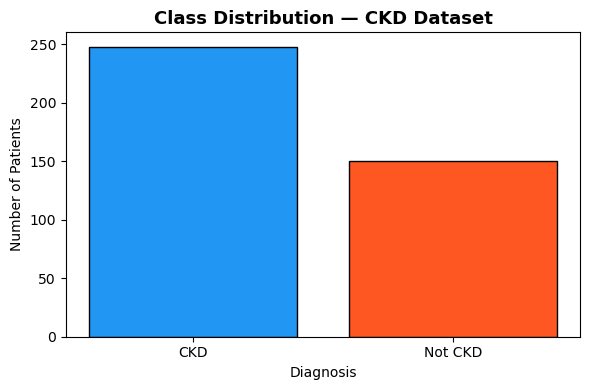

In [4]:
# Class Distribution
counts = df['classification'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['CKD', 'Not CKD'],
       [counts.get('ckd', 0) + counts.get('ckd\\t', 0), counts.get('notckd', 0)],
       color=['#2196F3', '#FF5722'], edgecolor='black')
ax.set_title('Class Distribution — CKD Dataset', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.set_xlabel('Diagnosis')
plt.tight_layout()
plt.show()

Features with missing values:
       Count  Percentage
rbc      152        38.0
rc       130        32.5
wc       105        26.2
pot       88        22.0
sod       87        21.8
pcv       70        17.5
pc        65        16.2
hemo      52        13.0
su        49        12.2
sg        47        11.8
al        46        11.5
bgr       44        11.0
bu        19         4.8
sc        17         4.2
bp        12         3.0
age        9         2.2
pcc        4         1.0
ba         4         1.0
htn        2         0.5
dm         2         0.5
cad        2         0.5
appet      1         0.2
pe         1         0.2
ane        1         0.2


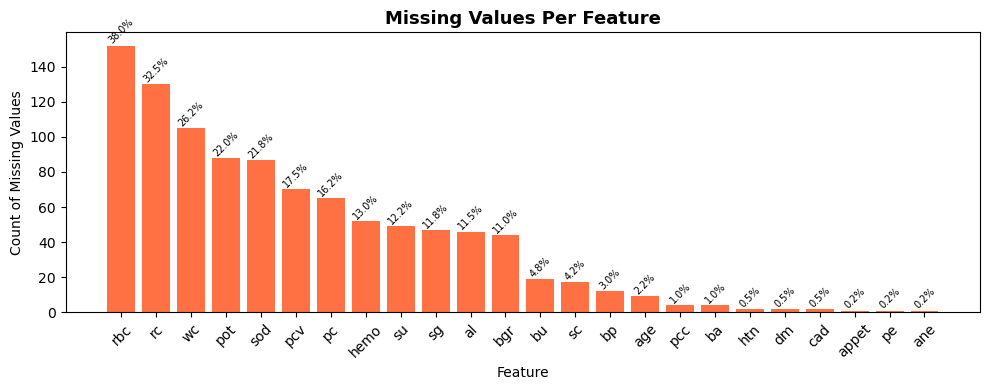

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)
print("Features with missing values:")
print(missing_df)

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(missing_df.index, missing_df['Count'], color='#FF7043')
ax.set_title('Missing Values Per Feature', fontsize=13, fontweight='bold')
ax.set_ylabel('Count of Missing Values')
ax.set_xlabel('Feature')
for i, (col, row) in enumerate(missing_df.iterrows()):
    ax.text(i, row['Count'] + 1, f"{row['Percentage']}%", ha='center', fontsize=7, rotation=45)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
data = pd.read_csv("kidney_disease.csv")

data.columns = data.columns.str.strip()

data = data.drop('id', axis=1)
print("'id' column dropped.")

data.replace('?', np.nan, inplace=True)

numeric_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu',
                'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data['classification'] = data['classification'].astype(str).str.strip().str.lower()
data['classification'] = data['classification'].replace({'ckd\t': 'ckd'})
data['classification'] = data['classification'].map({'ckd': 1, 'notckd': 0})
data = data.dropna(subset=['classification'])
data['classification'] = data['classification'].astype(int)

print("Target value counts:", data['classification'].value_counts().to_dict())

cat_encoding = {
    'rbc':   {'normal': 1, 'abnormal': 0},
    'pc':    {'normal': 1, 'abnormal': 0},
    'pcc':   {'present': 1, 'notpresent': 0},
    'ba':    {'present': 1, 'notpresent': 0},
    'htn':   {'yes': 1, 'no': 0},
    'dm':    {'yes': 1, 'no': 0},
    'cad':   {'yes': 1, 'no': 0},
    'appet': {'good': 1, 'poor': 0},
    'pe':    {'yes': 1, 'no': 0},
    'ane':   {'yes': 1, 'no': 0}
}
for col, mapping in cat_encoding.items():
    data[col] = data[col].astype(str).str.strip().str.lower().map(mapping)

print("\nData types after encoding:")
print(data.dtypes)
print("\nFinal missing values per column:")
print(data.isnull().sum())
print("\nDataset shape after preprocessing:", data.shape)

'id' column dropped.
Target value counts: {1: 250, 0: 150}

Data types after encoding:
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc               float64
pc                float64
pcc               float64
ba                float64
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn               float64
dm                float64
cad               float64
appet             float64
pe                float64
ane               float64
classification      int64
dtype: object

Final missing values per column:
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr              

In [7]:
X = data.drop('classification', axis=1)   #  input features
y = data['classification']                # Target value -> 1 = CKD, 0 = Not CKD

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print("\nFeatures used:")
print(list(X.columns))

Feature matrix X shape: (400, 24)
Target vector y shape: (400,)

Features used:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # Preserve class proportions
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")
print(f"\nClass distribution in training set: {y_train.value_counts().to_dict()}")
print(f"Class distribution in test set    : {y_test.value_counts().to_dict()}")

Training samples : 320
Test samples     : 80
Features         : 24

Class distribution in training set: {1: 200, 0: 120}
Class distribution in test set    : {1: 50, 0: 30}


In [9]:
# Fit imputer on training data ONLY
imputer = SimpleImputer(strategy='mean')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print("Missing values in training set after imputation:", X_train_imp.isnull().sum().sum())
print("Missing values in test set after imputation    :", X_test_imp.isnull().sum().sum())

Missing values in training set after imputation: 0
Missing values in test set after imputation    : 0


In [10]:
# Train default Random Forest (100 trees, all other defaults)
rf_default = RandomForestClassifier(n_estimators=100, random_state=42)
rf_default.fit(X_train_imp, y_train)

y_pred_default = rf_default.predict(X_test_imp)
y_prob_default = rf_default.predict_proba(X_test_imp)[:, 1]

print("=== DEFAULT RANDOM FOREST — Results ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_default)*100:.2f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_default):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, target_names=['Not CKD', 'CKD']))

=== DEFAULT RANDOM FOREST — Results ===
Accuracy  : 100.00%
ROC-AUC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [11]:
param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [None, 5, 10, 20],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_imp, y_train)

print("\nBest Parameters   :", grid_search.best_params_)
print(f"Best CV Accuracy  : {grid_search.best_score_*100:.2f}%")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters   : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Accuracy  : 99.69%


In [12]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test_imp)
y_prob_best = best_rf.predict_proba(X_test_imp)[:, 1]

acc      = accuracy_score(y_test, y_pred_best)
prec     = precision_score(y_test, y_pred_best)
rec      = recall_score(y_test, y_pred_best)
f1       = f1_score(y_test, y_pred_best)
roc_auc  = roc_auc_score(y_test, y_prob_best)

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print("=" * 52)
print("  RANDOM FOREST (TUNED) — RESULTS SUMMARY")
print("=" * 52)
print(f"  Dataset       : Chronic Kidney Disease")
print(f"  Total samples : {len(data)}")
print(f"  Train/Test    : 80% / 20%")
print(f"  Features used : {X_train_imp.shape[1]}")
print("-" * 52)
print(f"  Accuracy      : {acc*100:.2f}%")
print(f"  Precision     : {prec:.4f}")
print(f"  Recall        : {rec:.4f}")
print(f"  F1 Score      : {f1:.4f}")
print(f"  ROC-AUC       : {roc_auc:.4f}")
print("-" * 52)
print(f"  True Positives  (CKD correctly detected)    : {tp}")
print(f"  True Negatives  (Healthy correctly cleared) : {tn}")
print(f"  False Positives (Healthy wrongly flagged)   : {fp}")
print(f"  False Negatives (CKD missed)                : {fn}")
print("=" * 52)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Not CKD', 'CKD']))

  RANDOM FOREST (TUNED) — RESULTS SUMMARY
  Dataset       : Chronic Kidney Disease
  Total samples : 400
  Train/Test    : 80% / 20%
  Features used : 24
----------------------------------------------------
  Accuracy      : 100.00%
  Precision     : 1.0000
  Recall        : 1.0000
  F1 Score      : 1.0000
  ROC-AUC       : 1.0000
----------------------------------------------------
  True Positives  (CKD correctly detected)    : 50
  True Negatives  (Healthy correctly cleared) : 30
  False Positives (Healthy wrongly flagged)   : 0
  False Negatives (CKD missed)                : 0

Classification Report:
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



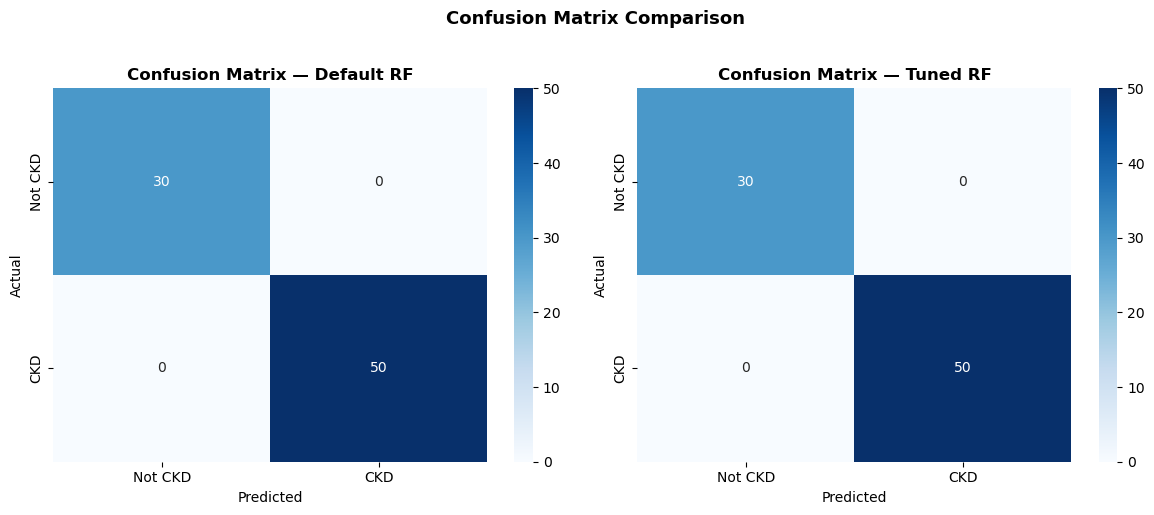

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm_data, pred, title in [
    (axes[0], confusion_matrix(y_test, y_pred_default), y_pred_default, 'Default RF'),
    (axes[1], confusion_matrix(y_test, y_pred_best),    y_pred_best,    'Tuned RF')
]:
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not CKD', 'CKD'],
                yticklabels=['Not CKD', 'CKD'])
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrix Comparison', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


=== 10-Fold Cross-Validation ===
Scores : [1.    0.975 1.    1.    0.975 1.    1.    1.    1.    1.   ]
Mean   : 0.9950  (99.50%)
Std    : 0.0100


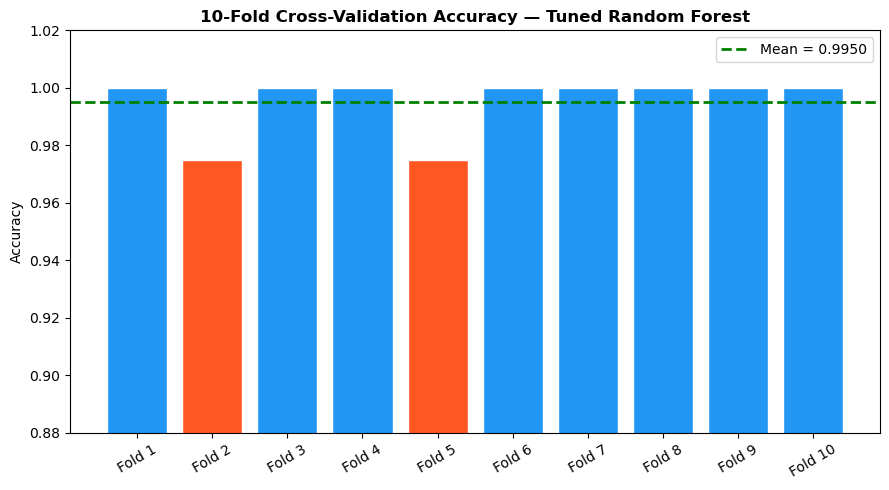

In [16]:
# Use the full imputed dataset for CV
X_all_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

cv_scores = cross_val_score(best_rf, X_all_imp, y, cv=10, scoring='accuracy')

print("=== 10-Fold Cross-Validation ===")
print(f"Scores : {cv_scores.round(4)}")
print(f"Mean   : {cv_scores.mean():.4f}  ({cv_scores.mean()*100:.2f}%)")
print(f"Std    : {cv_scores.std():.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(9, 5))
folds = [f'Fold {i+1}' for i in range(10)]
bar_colors = ['#2196F3' if s == 1.0 else '#FF5722' for s in cv_scores]
ax.bar(folds, cv_scores, color=bar_colors, edgecolor='white')
ax.axhline(y=cv_scores.mean(), color='green', linestyle='--', lw=2,
           label=f'Mean = {cv_scores.mean():.4f}')
ax.set_title('10-Fold Cross-Validation Accuracy — Tuned Random Forest', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim([0.88, 1.02])
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [15]:
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Default RF': [
        accuracy_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_default),
        roc_auc_score(y_test, y_prob_default)
    ],
    'Tuned RF': [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best),
        roc_auc_score(y_test, y_prob_best)
    ]
}).set_index('Metric').round(4)

print("=== Final Results Comparison ===")
print(summary.to_string())

=== Final Results Comparison ===
           Default RF  Tuned RF
Metric                         
Accuracy          1.0       1.0
Precision         1.0       1.0
Recall            1.0       1.0
F1 Score          1.0       1.0
ROC-AUC           1.0       1.0
